In [4]:
from ergochemics.draw import draw_reaction
import polars as pl
from ergochemics.mapping import operator_map_reaction
from rdkit import Chem
from rdkit.Chem import AllChem

In [11]:
from rdkit import Chem
from rdkit.Chem import rdChemReactions
from rdkit.Chem.rdchem import ChiralType
import re
from typing import Iterable
from pydantic import BaseModel
from itertools import permutations, product, chain, accumulate
from functools import lru_cache
import numpy as np
from ergochemics.standardize import (
    standardize_reaction,
    fast_tautomerize
)

class OperatorMapResult(BaseModel):
    '''
    Result of mapping a reaction to a reaction operator.
    
    Attributes
    ----------
    did_map:bool
        Whether the mapping was successful
    aligned_smarts:str | None
        Reaction SMARTS with reactants and products
        aligned to the operator reactants and products
    atom_mapped_smarts:str | None
        Reaction SMARTS with atom map numbers
    template_aidxs:tuple[tuple[int]] | None
        Template atom indices. Outer
        iterable is len 2,
        next iterable is len n rcts or n prods,
        next is len(n template_aidxs in molecule i)
    '''
    did_map: bool
    aligned_smarts: str | None = None
    atom_mapped_smarts: str | None = None
    template_aidxs: tuple[tuple[tuple[int, ...], ...], tuple[tuple[int, ...], ...]] | None = None

MAPPING_STANDARDIZATION_DEFAULTS = {
    'do_canon_taut':False,
    'do_neutralize':True,
    'do_find_parent':False,
    'do_remove_stereo':True,
    "neutralization_method": "simple",
    'quiet': False,
}

@lru_cache(maxsize=1000)
def _m_standardize_reaction(rxn: str, **kwargs) -> str:
    return standardize_reaction(rxn, **kwargs)

@lru_cache(maxsize=1000)
def _cached_fast_tautomerize(smiles: str) -> str:
    return fast_tautomerize(smiles)

def _tautomer_expand(lhs: Iterable[str], rhs: Iterable[str]) -> list[tuple[tuple[str, ...], tuple[str, ...]]]:
    '''
    Expands reactants and products using fast_tautomerize
    and returns all combinations of reactants and products.

    Args
    ----
    lhs:Iterable[str]
        Reactants
    rhs:Iterable[str]
        Products

    Returns
    -------
    list[tuple[tuple[str, ...], tuple[str, ...]]]
        All combinations of reactants and products
    '''
    lhs = [_cached_fast_tautomerize(r) for r in lhs]
    rhs = [_cached_fast_tautomerize(p) for p in rhs]

    return list(product(product(*lhs), product(*rhs)))

def operator_map_reaction(rxn: str, operator: str, max_outputs=10_000) -> OperatorMapResult:
    '''
    Attempts to map operator to reaction.

    Note: The returned reaction center is really the set of all atoms specified in the 
    operator template. It is only truly the reaction center when the operator is minimal,
    i.e., its template only specifies the reaction center.
    
    Args
    ----
    rxn:str
        Reaction SMILES
    operator:str
        Reaction operator in SMARTS
    max_outputs:int
        Maximum number of outputs to generate w/ operator

    Returns
    -------
    :OperatorMapResult
        Result of mapping w/ attributes:
        - did_map:bool
            || Whether the mapping was successful
        - aligned_smarts:str | None
            || Reaction SMARTS with reactants and products
            aligned to the operator reactants and products
        - atom_mapped_smarts:str | None
            || Reaction SMARTS with atom map numbers
        - template_aidxs:tuple[tuple[int]] | None
            || Template atom indices. Outer
            iterable is len 2,
            next iterable is len n rcts or n prods,
            next is len(n template_aidxs in molecule i)
    '''
    try:
        rxn = _m_standardize_reaction(rxn, **MAPPING_STANDARDIZATION_DEFAULTS)
    except:
        print(f"Error standardizing reaction: {rxn}")
        return OperatorMapResult(did_map=False)
    
    rcts, pdts = [elt.split('.') for elt in rxn.split('>>')]
    op_lhs, op_rhs = extract_operator_patts(operator)

    if [len(rcts), len(pdts)] != [len(op_lhs), len(op_rhs)]: # First check cardinality
        return OperatorMapResult(did_map=False)
    
    op = rdChemReactions.ReactionFromSmarts(operator) # Make reaction object from smarts string

    for taut_rcts, taut_pdts in _tautomer_expand(rcts, pdts): # Iterate over tautomer combinations
        
        rcts_mol = [Chem.MolFromSmiles(r) for r in taut_rcts]

        if any([m is None for m in rcts_mol]):
            print(f"Error parsing tautomerized reactant for: {rxn}")
            continue

        # Mark reactant atoms for atom mapping
        for i, m in enumerate(rcts_mol):
            for atom in m.GetAtoms():
                atom.SetIntProp('reactant_idx', i)

        # Preserve mapping of op am numbers to op reactant indices, i.e., which reactant template
        # each atom map number belongs to (will lose this after running operator)
        am_to_reactant_idx ={}
        for ri in range(op.GetNumReactantTemplates()):
            rt = op.GetReactantTemplate(ri)
            for atom in rt.GetAtoms():
                if atom.GetAtomMapNum():
                    am_to_reactant_idx[atom.GetAtomMapNum()] = ri
        
        matched_idxs = permutations([i for i in range(len(taut_rcts))])

        lhs_patts = [Chem.MolFromSmarts(l) for l in op_lhs]
        for idx_perm in matched_idxs:
            perm = [rcts_mol[idx] for idx in idx_perm]
            substruct_matches = [perm[i].GetSubstructMatches(lp) for i, lp in enumerate(lhs_patts)]

            if any([len(elt) == 0 for elt in substruct_matches]): # Check if this permutation of reactants matches operator templates
                continue

            ss_match_combos = product(*substruct_matches) # All combos of putative rcs of n substrates
            all_putative_rc_atoms = [set(chain(*elt)) for elt in substruct_matches] # ith element has set of all putative rc atoms of ith reactant

            for smc in ss_match_combos:

                # Protect all but rc currently considered in each reactant
                for j, reactant_rc in enumerate(smc):
                    all_but = all_putative_rc_atoms[j] - set(reactant_rc) 
                    for protect_idx in all_but:
                        perm[j].GetAtomWithIdx(protect_idx).SetProp('_protected', '1')

                outputs = op.RunReactants(perm, maxProducts=max_outputs)

                correct_output = _compare_operator_outputs_w_products(outputs, taut_pdts)

                if correct_output is not None:
                    aligned_rxn, am_rxn, rhs_template_aidxs = _finalize_mapped_reaction(reactants=perm, output=correct_output, permuted_idxs=idx_perm, am_to_reactant_idx=am_to_reactant_idx)
                    template_aidxs = tuple([smc, rhs_template_aidxs])
                    return OperatorMapResult(
                        did_map=True,
                        aligned_smarts=aligned_rxn,
                        atom_mapped_smarts=am_rxn,
                        template_aidxs=template_aidxs
                    )

                # Deprotect & try again
                for j, reactant_rc in enumerate(smc):
                    all_but = all_putative_rc_atoms[j] - set(reactant_rc)
                    for protect_idx in all_but:
                        perm[j].GetAtomWithIdx(protect_idx).ClearProp('_protected')

    return OperatorMapResult(did_map=False) # Did not map

def _compare_operator_outputs_w_products(outputs: tuple[tuple[Chem.Mol]], products: list[str]) -> tuple[Chem.Mol] | None:
    '''
    Compares operator outputs to products and
    returns the products in the order of the operator outputs.
    Returns empty list if no match is found.
    '''
    srt_prod = tuple(sorted(products))

    for output in outputs:
        try:
            output_smi = [(Chem.MolToSmiles(mol), i) for i, mol in enumerate(output)]
            srt_out_smi, srt_oidx = zip(*sorted(output_smi, key=lambda x: x[0]))
        except:
            continue

        if srt_out_smi == srt_prod:
            return output    

    return None

def _finalize_mapped_reaction(reactants: Iterable[Chem.Mol], output: Iterable[Chem.Mol], permuted_idxs: list[int], am_to_reactant_idx: dict[int, int]) -> tuple[str, str, tuple[tuple[int, ...], tuple[int, ...]]]:
    '''
    Args
    ----
    reactants:Iterable[Chem.Mol]
        Reactants. Note: must be ordered as they match
        lhs operator templates
    output:Iterable[Chem.Mol]
        Output from operator.RunReactants(reactants) that
        matches the actual products
    permuted_idxs:list[int]
        Original indices of reactants in reaction,
        permuted to match the operator
    am_to_reactant_idx:dict[int, int]
        Mapping of atom map numbers to reactant indices
        (i.e. which reactant the atom map number belongs to)
    
    Returns
    -------
    :tuple[str, str, tuple[tuple[int, ...], tuple[int, ...]]]
        Operator aligned reaction without atom mapping
        Operator aligned reaction WITH atom mapping
        Reaction center indices
    '''
    aligned_no_am = '.'.join([Chem.MolToSmiles(m) for m in reactants]) + '>>' + '.'.join([Chem.MolToSmiles(m) for m in output])

    am = 1
    rhs_am_rc = []
    for prod in output:
        for atom in prod.GetAtoms():
            atom.SetAtomMapNum(am)
            props = atom.GetPropsAsDict()
            rct_atom_idx = props.get('react_atom_idx')
            rct_idx = props.get('reactant_idx')
            old_am = props.get('old_mapno')
            
            if rct_idx is not None:
                reactants[permuted_idxs.index(rct_idx)].GetAtomWithIdx(rct_atom_idx).SetAtomMapNum(am)
            elif old_am is not None:
                print(props)
                rct_idx = am_to_reactant_idx[old_am]
                reactants[rct_idx].GetAtomWithIdx(rct_atom_idx).SetAtomMapNum(am)
                rhs_am_rc.append(atom.GetAtomMapNum())
            else:
                continue
                
            am += 1

    # Reaction.RunReactants() outputs do not have atoms ordered according to their
    # canonical SMILES ordering. Must go back and forth betweeen SMILES and mol, 
    # then label according to atom map numbers
    try:
        rhs_am_smiles = [Chem.MolToSmiles(m, ignoreAtomMapNumbers=True) for m in output]
    except Exception as e:
        if e.__class__.__name__ == 'ArgumentError':
            raise ValueError("RDKit ArgumentError encountered when generating SMILES from reaction output. Returning unmapped result.")
        
    rhs_am_recap = [Chem.MolFromSmiles(smi) for smi in rhs_am_smiles]
    rhs_rc = []
    for mol in rhs_am_recap:
        inner_rc = []
        for atom in mol.GetAtoms():
            if atom.GetAtomMapNum() in rhs_am_rc:
                inner_rc.append(atom.GetIdx())
        rhs_rc.append(tuple(inner_rc))
    rhs_rc = tuple(rhs_rc)

    aligned_with_am = '.'.join([Chem.MolToSmiles(m, ignoreAtomMapNumbers=True) for m in reactants]) + '>>' + '.'.join(rhs_am_smiles)
    return aligned_no_am, aligned_with_am, rhs_rc

def extract_operator_patts(smarts: str) -> tuple[tuple[str]]:
    '''
    Pulls SMARTS patterns from a reaction SMARTS string.
    
    Args
    ----
    smarts:str
        Reaction SMARTS
    
    Returns
    -------
    tuple[tuple[str]]
        Tuple of tuples of SMARTS patterns. Each tuple corresponds
        to a side of the reaction operator. Each pattern corresponds
        to the part of the reaction center contained within a given molecule.
    '''
    patts = []
    for side in smarts.split('>>'):
        smarts = re.sub(r':[0-9]+]', ']', side)

        # Identify each fragment
        side_patts = []
        temp_fragment = []

        # Append complete fragments only
        for fragment in smarts.split('.'):
            temp_fragment += [fragment]
            if '.'.join(temp_fragment).count('(') == '.'.join(temp_fragment).count(')'):
                side_patts.append('.'.join(temp_fragment))
                temp_fragment = []

                # Remove component grouping for substructure matching
                if '.' in side_patts[-1]:
                    side_patts[-1] = side_patts[-1].replace('(', '', 1)[::-1].replace(')', '', 1)[::-1]

        patts.append(tuple(side_patts))

    return tuple(patts)

def rc_to_str(rc: Iterable[Iterable[Iterable[int]]]) -> str:
    '''
    Convert nested tuple representation of atom indices (e.g., for reaction center) to string representation.
    If rc is a 2-level nested tuple, it is assumed this corresponds to the left-hand side 
    of the reaction.
    '''
    return ">>".join(
        [
            ";".join(
                [
                    ",".join(
                    [str(aidx) for aidx in mol]
                    )
                    for mol in side
                ]
            )
            for side in rc
        ]
    )

def rc_to_nest(rc: str) -> tuple[tuple[tuple[int]]]:
    '''
    Convert string representation of atom indices (e.g., for reaction center) to nested tuple representation.
    '''
    return tuple(
        tuple(
            tuple(
                int(aidx) for aidx in mol.split(",") if aidx != ""
            )
            for mol in side.split(";")
        )
        for side in rc.split(">>")
    )

def get_reaction_center(am_rxn: str, mode: str = "separate", include_stereo: bool = False) -> list[list[list[int]], list[list[int]]] | list[list[int], list[int]]:
    '''
    Get reaction center from reaction SMARTS with atom mapping.
    
    Args
    ----
    am_rxn:str
        Reaction SMARTS with atom mapping. Must be in the form of
        "R1.R2>>P1.P2" where R1 and R2 are reactants and P1 and P2 are products.
    mode:str
        Mode of operation. If "separate", returns reaction center indices
        for reactants and products separately. If "combined", returns a single
        list of reaction center indices for each side of the reaction.
    
    Returns
    -------
    tuple[tuple[tuple[int]], tuple[tuple[int]]] | tuple[tuple[int], tuple[int]]
        If mode is "separate", returns a tuple of tuples of tuples of reaction center indices
        for each molecule for each side of the reaction.
        If mode is "combined", returns a tuple of tuples of reaction center indices for each side of the reaction,
        treating each side as a combined, disjoint molecule.

    Notes
    -----
    rdkit Chem.MolFromSmiles() indexes atoms in the order they appear in the SMILES string. This
    is true whether the SMILES string has multiple molecules or not.
    '''
    if mode not in ["separate", "combined"]:
        raise ValueError("Mode must be 'separate' or 'combined'")

    sides = [elt.split('.') for elt in am_rxn.split('>>')]
    amn_to_midx_aidx = [] # Atom map num to mol idx, atom idx for lhs, rhs
    adj_mats = []
    offsets = []
    block_mols = []
    for side in sides:
        tmp = {}
        n_atoms = []
        for midx, smi in enumerate(side):
            mol = Chem.MolFromSmiles(smi)
            n_atoms.append(mol.GetNumAtoms())
            
            for atom in mol.GetAtoms():
                amn = atom.GetAtomMapNum()

                if amn == 0:
                    raise ValueError("All atoms in reaction SMARTS must have atom map numbers")

                tmp[amn] = (midx, atom.GetIdx())
        
        amn_to_midx_aidx.append(tmp)
        offsets.append([0] + list(accumulate(n_atoms)))

        block_smi = ".".join(side)
        block_mol = Chem.MolFromSmiles(block_smi)
        block_mols.append(block_mol)
        block_aidx_to_amn = {atom.GetIdx(): atom.GetAtomMapNum() for atom in block_mol.GetAtoms()}
        A = Chem.GetAdjacencyMatrix(mol=block_mol, useBO=True)
        srt_idx = sorted([i for i in range(A.shape[0])], key=lambda x : block_aidx_to_amn[x])
        A = A[:, srt_idx][srt_idx]
        adj_mats.append(A)

    D = np.abs(adj_mats[1] - adj_mats[0])

    if len(amn_to_midx_aidx[0].keys() ^ amn_to_midx_aidx[1].keys()) != 0:
        raise ValueError("LHS and RHS atom maps do not perfectly intersect")

    rc_amns = list(np.flatnonzero(D.sum(axis=1)) + 1)

    if include_stereo:
        rc_amns = _add_stereo_double_bond_atoms(block_mols, rc_amns)
        rc_amns = _add_chiral_center_atoms(block_mols, rc_amns)
    
    if mode == "separate":
        tmp = [[[] for _ in range(len(side))] for side in sides]
        for amn in rc_amns:
            for side_idx, lookup in enumerate(amn_to_midx_aidx):
                midx, aidx = lookup[amn]
                tmp[side_idx][midx].append(aidx)

        reaction_center = tuple([tuple(tuple(sorted(mol_rc)) for mol_rc in side_rc) for side_rc in tmp])
    elif mode == "combined":
        tmp = [[], []]
        for amn in rc_amns:
            for side_idx, lookup in enumerate(amn_to_midx_aidx):
                midx, aidx = lookup[amn]
                tmp[side_idx].append(aidx + offsets[side_idx][midx])

        reaction_center = tuple([tuple(sorted(side_rc)) for side_rc in tmp])

    return reaction_center

def _add_stereo_double_bond_atoms(block_mols: list[Chem.Mol], rc_amns: list[int]) -> list[int]:
    '''
    Adds atom map numbers of atoms involved in stereo double bonds
    to the reaction center atom map numbers.

    Args
    ----
    block_mols:list[Chem.Mol]
        List of RDKit Mol objects for the left- and right-hand sides
        of the reaction.
    rc_amns:list[int]
        List of reaction center atom map numbers.

    Returns
    -------
    list[int]
        Updated list of reaction center atom map numbers.
    '''
    lhs_mol, rhs_mol = block_mols
    rhs_amn_to_aidx = {atom.GetAtomMapNum(): atom.GetIdx() for atom in rhs_mol.GetAtoms()}
    rc_amns = set(rc_amns)
    for lhs_bond in lhs_mol.GetBonds():
        if lhs_bond.GetBondType() == Chem.rdchem.BondType.DOUBLE and lhs_bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE:
            begin_aidx = lhs_bond.GetBeginAtom().GetIdx()
            end_aidx = lhs_bond.GetEndAtom().GetIdx()
            begin_amn = lhs_bond.GetBeginAtom().GetAtomMapNum()
            end_amn = lhs_bond.GetEndAtom().GetAtomMapNum()
            rhs_begin_aidx = rhs_amn_to_aidx[begin_amn]
            rhs_end_aidx = rhs_amn_to_aidx[end_amn]
            rhs_bond = rhs_mol.GetBondBetweenAtoms(rhs_begin_aidx, rhs_end_aidx)
            
            if rhs_bond is not None and rhs_bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE:
                rc_amns.add(begin_amn)
                rc_amns.add(end_amn)

                for nbr in lhs_mol.GetAtomWithIdx(begin_aidx).GetNeighbors():
                    rc_amns.add(nbr.GetAtomMapNum())
                for nbr in lhs_mol.GetAtomWithIdx(end_aidx).GetNeighbors():
                    rc_amns.add(nbr.GetAtomMapNum())
    
    return list(rc_amns)

def _add_chiral_center_atoms(block_mols: list[Chem.Mol], rc_amns: list[int]) -> list[int]:
    lhs_mol, rhs_mol = block_mols
    rhs_amn_to_aidx = {atom.GetAtomMapNum(): atom.GetIdx() for atom in rhs_mol.GetAtoms()}
    rc_amns = set(rc_amns)
    lhs_ctrs = [
        (elt[0], lhs_mol.GetAtomWithIdx(elt[0]).GetAtomMapNum()) for elt in Chem.FindMolChiralCenters(lhs_mol) # (atom idx, atom map num)
    ]
    for (ctr_aidx, ctr_amn) in lhs_ctrs:
        rhs_aidx = rhs_amn_to_aidx[ctr_amn]
        rhs_atom = rhs_mol.GetAtomWithIdx(rhs_aidx)
        
        if rhs_atom.GetChiralTag() == ChiralType.CHI_UNSPECIFIED:
            continue
        
        lhs_tetra = _fragment_chiral_tetrahedral_wo_ams(lhs_mol, ctr_aidx)
        rhs_tetra = _fragment_chiral_tetrahedral_wo_ams(rhs_mol, rhs_aidx)
        
        if lhs_tetra != rhs_tetra:
            rc_amns.add(ctr_amn)
            for nbr in lhs_mol.GetAtomWithIdx(ctr_aidx).GetNeighbors():
                rc_amns.add(nbr.GetAtomMapNum())
    
    return list(rc_amns)

def _fragment_chiral_tetrahedral_wo_ams(mol: Chem.Mol, ctr_ids: int) -> str:
    neighbor_ids = [nbr.GetIdx() for nbr in mol.GetAtomWithIdx(ctr_ids).GetNeighbors()]
    am_sma = Chem.MolFragmentToSmarts(mol, atomsToUse=[ctr_ids] + neighbor_ids)
    sma = Chem.MolToSmarts(Chem.MolFromSmarts(am_sma))
    return sma

In [12]:
rule = '[#6:1][C:2]#[N:3]>>[#6:1][#6H1:2]=[#7:3][#8]'
rxn = 'N#Cc1ccco1>>ON=Cc1ccco1'
operator_map_reaction(rxn, rule)

{'old_mapno': 1, 'react_atom_idx': 2, 'react_idx': 0, 'molAtomMapNumber': 1}
{'_QueryHCount': 1, 'old_mapno': 2, 'react_atom_idx': 1, 'react_idx': 0, 'molAtomMapNumber': 2}
{'_ReactionDegreeChanged': 1, 'old_mapno': 3, 'react_atom_idx': 0, 'react_idx': 0, 'molAtomMapNumber': 3}


[17:28:08] Initializing MetalDisconnector
[17:28:08] Running MetalDisconnector
[17:28:08] Initializing Normalizer
[17:28:08] Running Normalizer
[17:28:08] Initializing MetalDisconnector
[17:28:08] Running MetalDisconnector
[17:28:08] Initializing Normalizer
[17:28:08] Running Normalizer


OperatorMapResult(did_map=True, aligned_smarts='N#Cc1ccco1>>ON=Cc1ccco1', atom_mapped_smarts='[N:3]#[C:2][c:1]1[cH:4][cH:6][cH:7][o:5]1>>[OH:4][N:3]=[CH:2][c:1]1[cH:4][cH:6][cH:7][o:5]1', template_aidxs=(((2, 1, 0),), ((1, 2, 3),)))

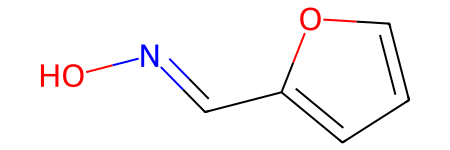

In [6]:
_op = AllChem.ReactionFromSmarts(rule)
_op.RunReactants([Chem.MolFromSmiles('N#Cc1ccco1')])[0][0]